In [ ]:
# Step 0: Imports
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Load the preprocessed data
df = pd.read_csv('../data/preprocessed/marketing_campaign_preprocessed.csv')

In [3]:
# ==============================
# 1. Feature Selection
# ==============================

segmentation_df = df.copy()

drop_cols = [
    'AcceptedCmp1','AcceptedCmp2','AcceptedCmp3',
    'AcceptedCmp4','AcceptedCmp5',
    'Response','Complain'
]

segmentation_df = segmentation_df.drop(columns=drop_cols)

print("Segmentation dataset shape:", segmentation_df.shape)

Segmentation dataset shape: (2229, 21)


In [4]:
# ==============================
# 2. Preprocessing Pipeline
# ==============================

from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

numeric_features = segmentation_df.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_features = segmentation_df.select_dtypes(include=['object']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ]
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor)
])

X_processed = pipeline.fit_transform(segmentation_df)

print("Processed shape:", X_processed.shape)

Processed shape: (2229, 23)


C:\Users\ibjio\AppData\Local\Temp\ipykernel_29644\1128354231.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = segmentation_df.select_dtypes(include=['object']).columns.tolist()


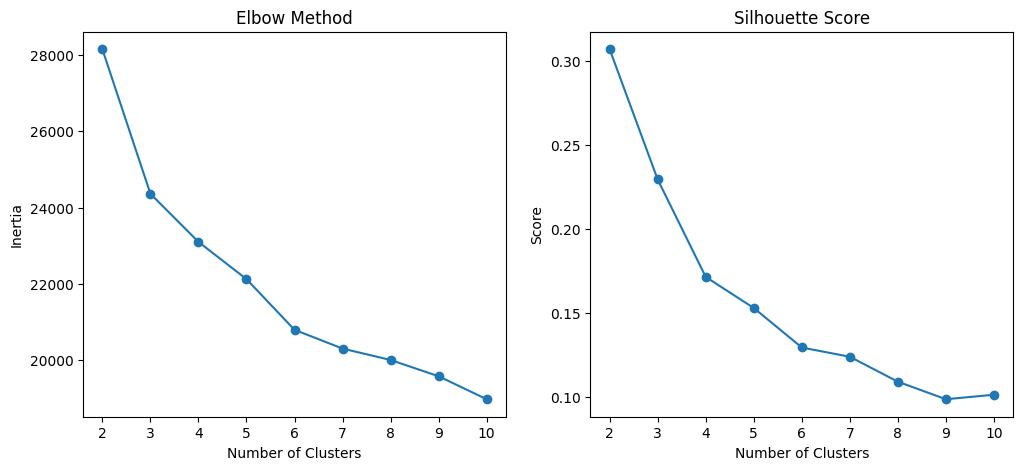

In [5]:
# ==============================
# 3. Determine Optimal Clusters
# ==============================

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_processed)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_processed, labels))

# Plot Elbow
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

# Plot Silhouette
plt.subplot(1,2,2)
plt.plot(K_range, silhouette_scores, marker='o')
plt.title("Silhouette Score")
plt.xlabel("Number of Clusters")
plt.ylabel("Score")

plt.show()

In [6]:
optimal_k = 4

In [7]:
# ==============================
# 4. Final Model
# ==============================

kmeans = KMeans(n_clusters=optimal_k, random_state=42)
segmentation_df['Cluster'] = kmeans.fit_predict(X_processed)

segmentation_df['Cluster'].value_counts()

Cluster
1    841
3    496
0    488
2    404
Name: count, dtype: int64

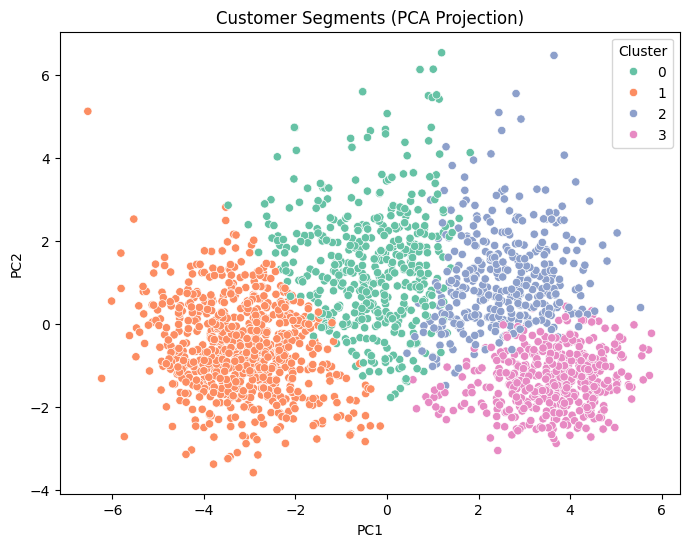

In [8]:
# ==============================
# 5. PCA Visualization
# ==============================

from sklearn.decomposition import PCA
import seaborn as sns

pca = PCA(n_components=2)
components = pca.fit_transform(X_processed)

pca_df = pd.DataFrame(data=components, columns=['PC1','PC2'])
pca_df['Cluster'] = segmentation_df['Cluster']

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Set2'
)
plt.title("Customer Segments (PCA Projection)")
plt.show()

In [10]:
summary_cols = [
    'Age','Income','Total_Spending','Total_Purchases',
    'Recency','Customer_Tenure_Days','Family_Size'
]

cluster_profile = segmentation_df.groupby('Cluster')[summary_cols].mean().round(1)

display(cluster_profile)

,Age,Income,Total_Spending,Total_Purchases,Recency,Customer_Tenure_Days,Family_Size
Cluster,,,,,,,
0,60.2,49497.4,18.2,16.9,47.9,4662.1,3.0
1,53.8,32463.0,10.9,6.8,48.5,4566.4,2.9
2,59.3,64209.2,25.8,23.0,51.3,4686.1,2.7
3,57.8,75934.0,27.9,19.9,49.5,4592.2,1.6


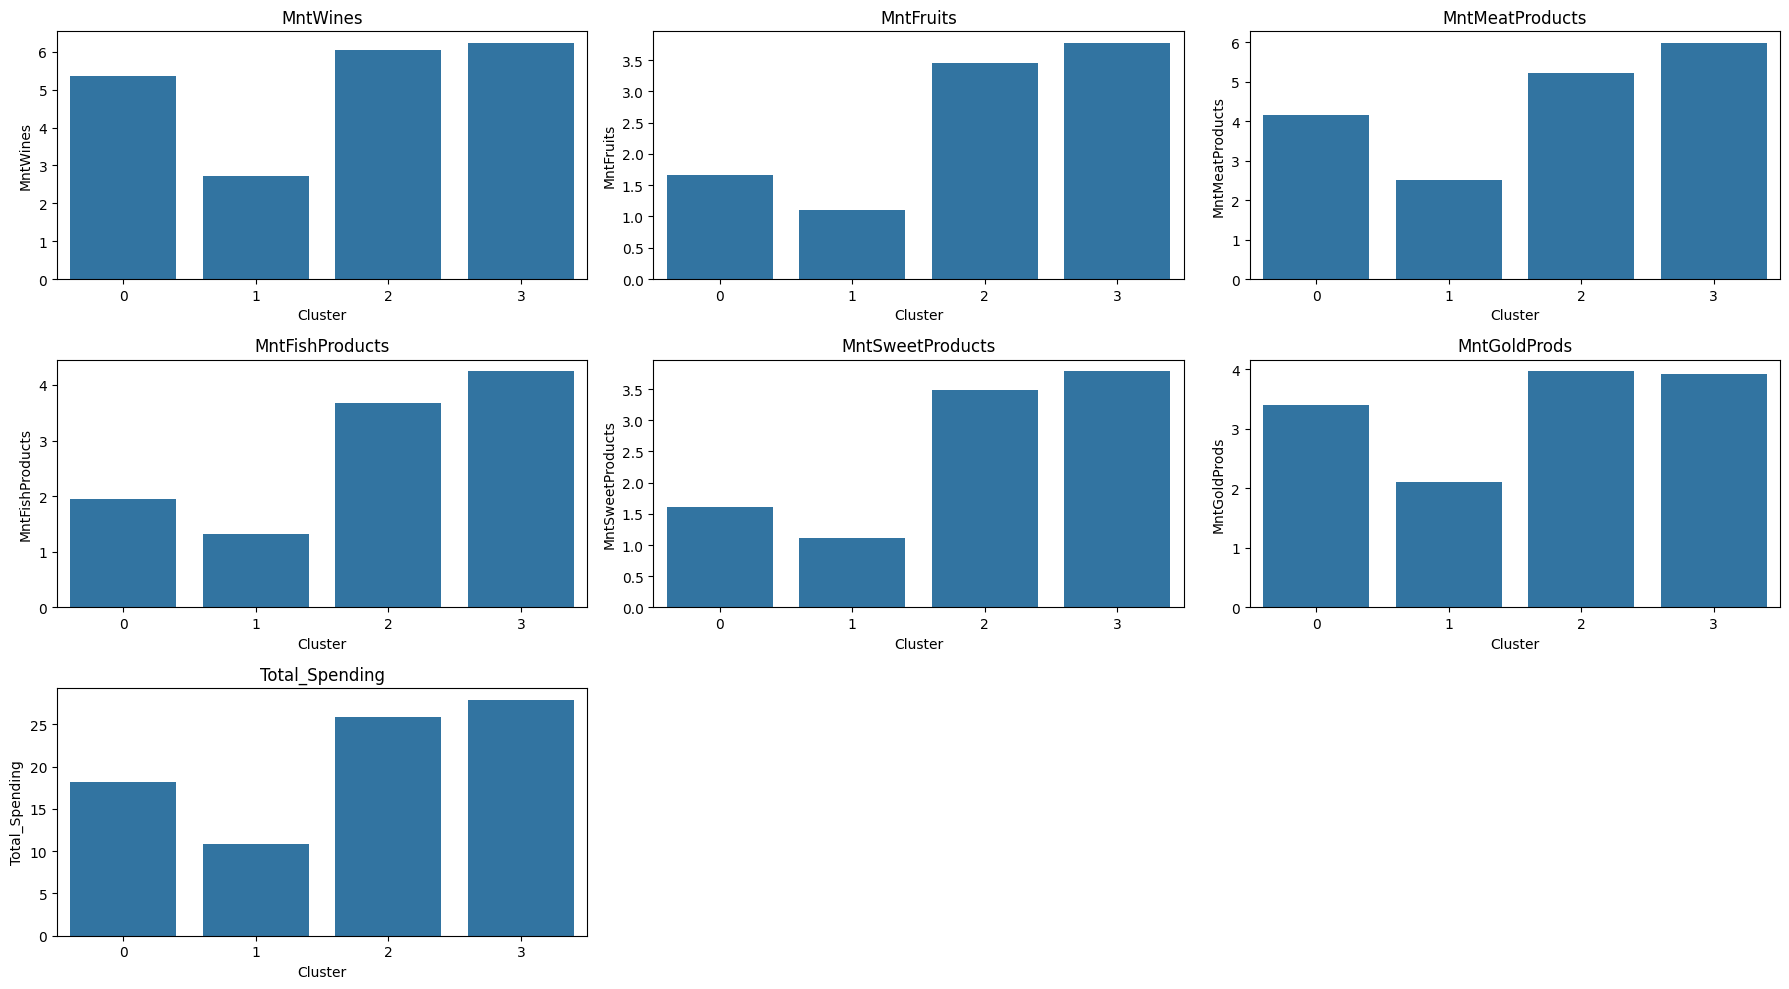

In [12]:
spend_cols = [
    'MntWines','MntFruits','MntMeatProducts',
    'MntFishProducts','MntSweetProducts',
    'MntGoldProds','Total_Spending'
]

n_cols = 3
n_rows = int(np.ceil(len(spend_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(spend_cols):
    sns.barplot(
        data=segmentation_df,
        x='Cluster',
        y=col,
        estimator=np.mean,
        errorbar=None,
        ax=axes[i]
    )
    axes[i].set_title(col)

# Remove empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

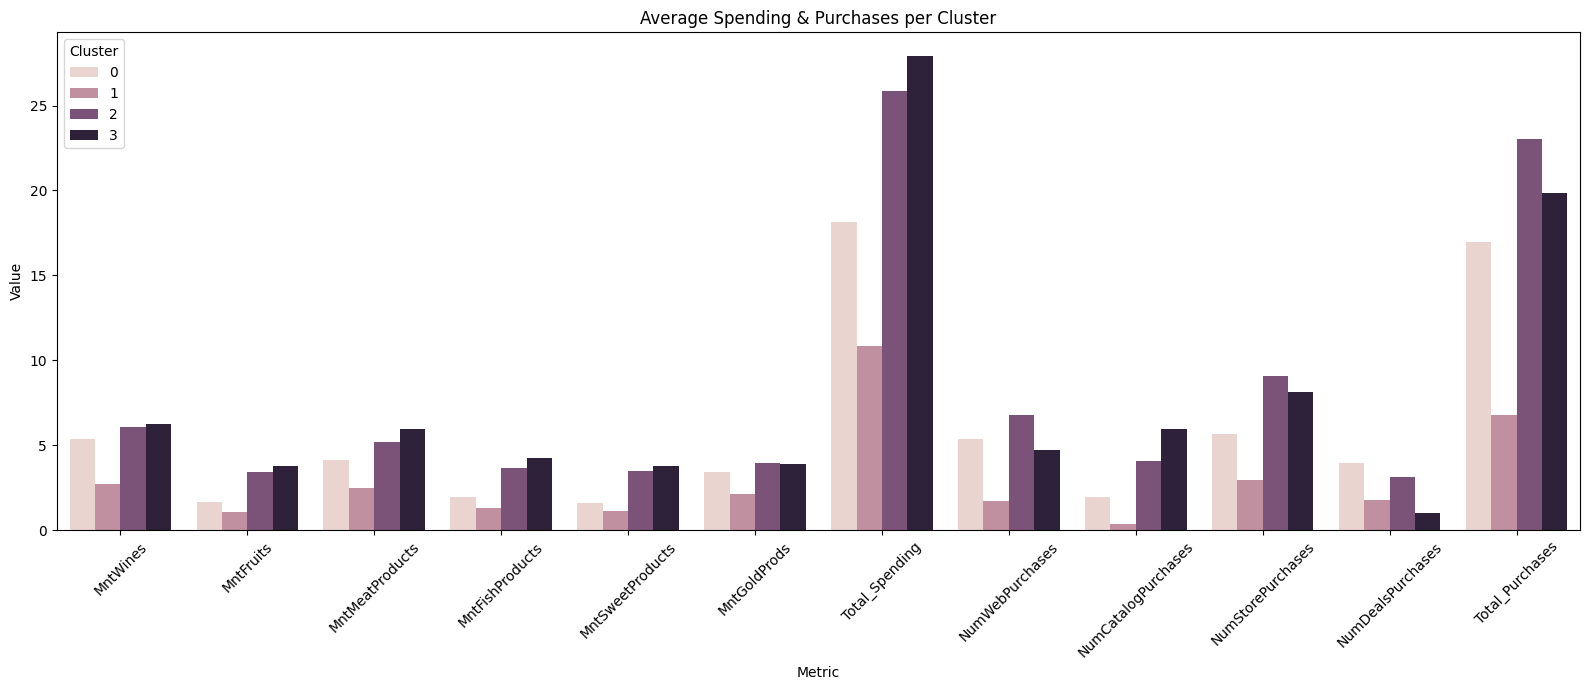

In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Columns to include
metrics = [
    # Spending
    'MntWines','MntFruits','MntMeatProducts',
    'MntFishProducts','MntSweetProducts','MntGoldProds',
    'Total_Spending',
    
    # Purchases
    'NumWebPurchases','NumCatalogPurchases',
    'NumStorePurchases','NumDealsPurchases',
    'Total_Purchases'
]

# Convert to long format
long_df = segmentation_df.melt(
    id_vars='Cluster',
    value_vars=metrics,
    var_name='Metric',
    value_name='Value'
)

plt.figure(figsize=(16,7))
sns.barplot(
    data=long_df,
    x='Metric',
    y='Value',
    hue='Cluster',
    estimator=np.mean,
    errorbar=None
)

plt.xticks(rotation=45)
plt.title("Average Spending & Purchases per Cluster")
plt.tight_layout()
plt.show()

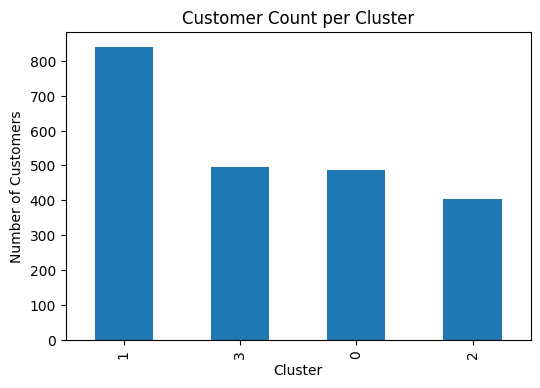

In [16]:
segmentation_df['Cluster'].value_counts().plot(
    kind='bar',
    figsize=(6,4),
    title='Customer Count per Cluster'
)
plt.ylabel('Number of Customers')
plt.show()

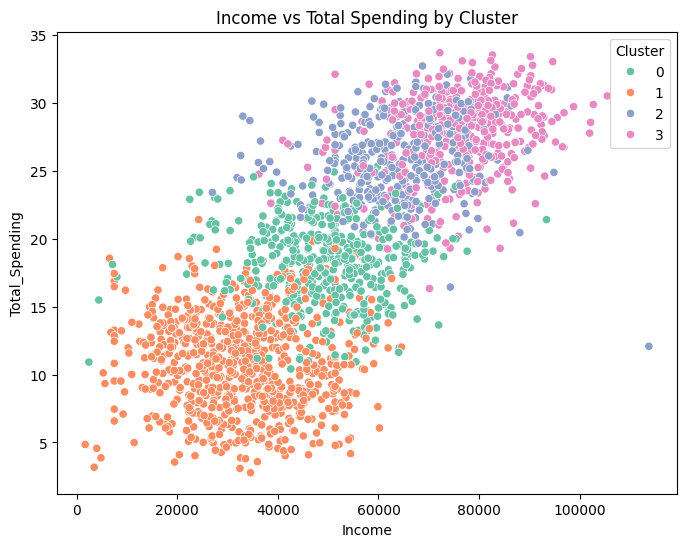

In [17]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=segmentation_df,
    x='Income',
    y='Total_Spending',
    hue='Cluster',
    palette='Set2'
)
plt.title("Income vs Total Spending by Cluster")
plt.show()

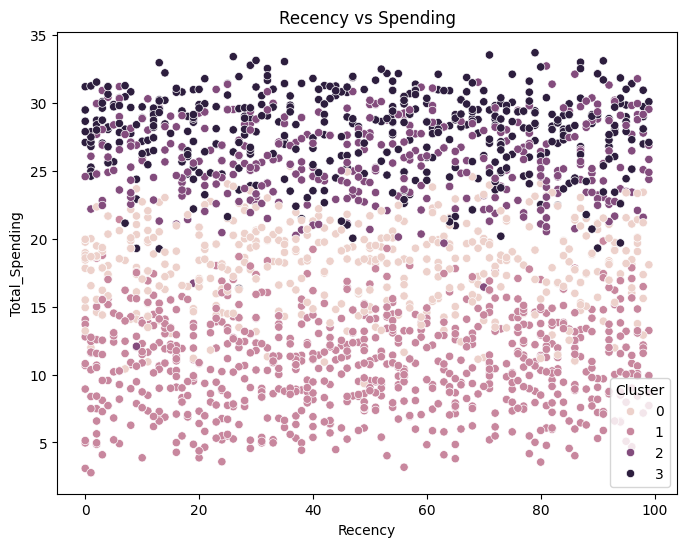

In [19]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=segmentation_df,
    x='Recency',
    y='Total_Spending',
    hue='Cluster'
)
plt.title("Recency vs Spending")
plt.show()

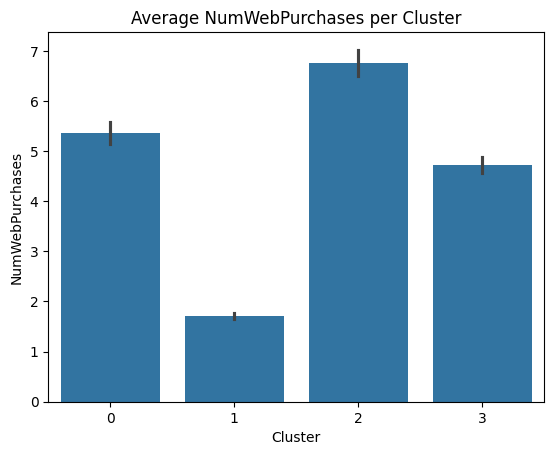

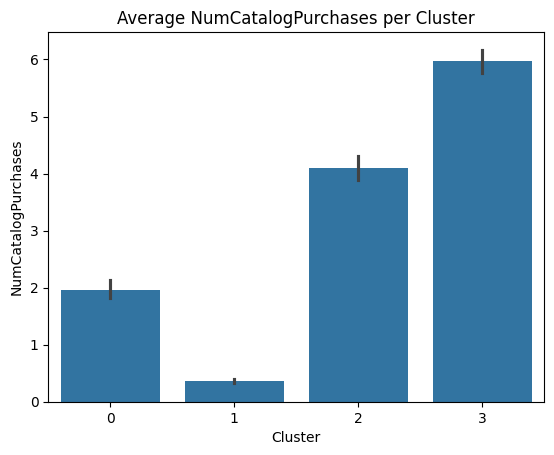

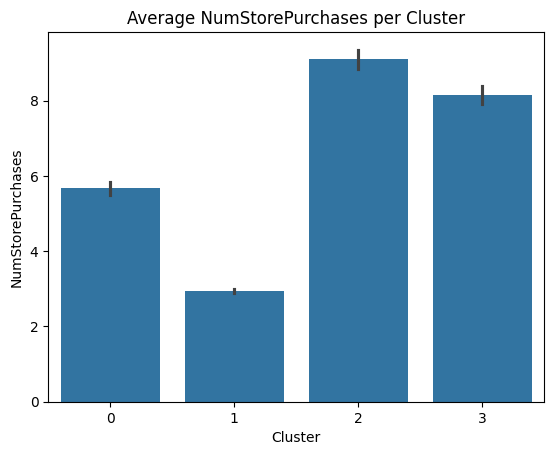

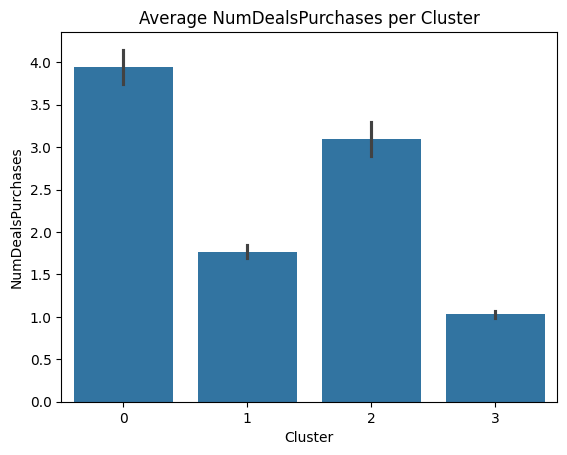

In [20]:
purchase_cols = [
    'NumWebPurchases',
    'NumCatalogPurchases',
    'NumStorePurchases',
    'NumDealsPurchases'
]

for col in purchase_cols:
    sns.barplot(data=segmentation_df, x='Cluster', y=col, estimator=np.mean)
    plt.title(f"Average {col} per Cluster")
    plt.show()

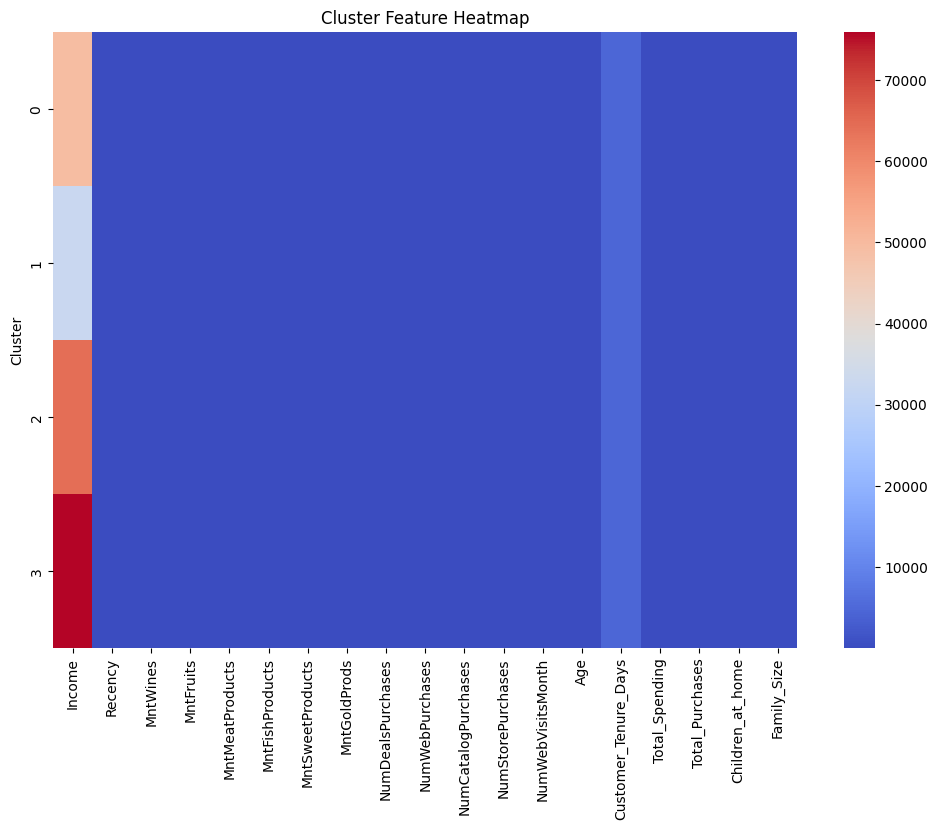

In [21]:
cluster_means = segmentation_df.groupby('Cluster').mean(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(cluster_means, cmap='coolwarm', annot=False)
plt.title("Cluster Feature Heatmap")
plt.show()

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans

full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('clusterer', KMeans(n_clusters=4, random_state=42))
])

full_pipeline.fit(segmentation_df.drop(columns=['Cluster'], errors='ignore'))

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('clusterer', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [15]:
import joblib
joblib.dump(full_pipeline, "customer_segmentation_pipeline.pkl")

['customer_segmentation_pipeline.pkl']